# Folding the roll into the factor basis

The headline model (`pca_factors.ipynb`) excludes the term-structure roll from both the
factor basis and the target, and treats it as a separately forecast carry line. This
notebook tests the alternative the roll-in view suggests: fold the roll into the pillar
changes *before* PCA, so each pillar tracks a **fixed option** — fixed strike *and*
fixed expiry. Yesterday's 1M ATM pillar is compared against today's vol at one month
*less one day* and at the slightly off-ATM moneyness where its strike now sits:

$$\Delta\sigma_{ij} \;=\; \sigma_t\!\left(\tau_i - dt,\; m_j \tfrac{S_0}{S_1}\right) - \sigma_{t-1}(\tau_i, m_j)$$

(`sticky_strike_dsigma(sd, include_roll=True)`, bicubic sampling, dt = calendar-day
gap / 365). This is the option's **own implied-vol change** — surface move + smile
slide + term roll — so `bucket_vega · Δσ` estimates the attribution's full `vol`
component directly, and the factor estimates should *add up* to it with no separate
carry line.

Two mechanical notes: the roll drift now lives inside the factor model (in the mean
term `bucket_vega·μ`), and the shortest TTM pillar clamps against the 0.08 grid edge,
losing a sliver of roll there.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from vol_pca import load_surfaces, simulate_book, fit_pca, factor_vega_estimates
from vol_pca.factors import factor_scores, sticky_strike_dsigma
from vol_pca.attribution import independent_attribution
from vol_pca.surface import TTM_PILLARS, MONEYNESS

C_ROLL, C_ALT, C_AUX = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUT = "#0b0b0b", "#898781"
DIV_CMAP = LinearSegmentedColormap.from_list("bwr_soft", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})
TTM_LBL = ["1M", "2M", "3M", "4M", "6M", "8M", "10M", "12M"]
MON_LBL = [str(int(m)) for m in MONEYNESS]
nt, nm = len(TTM_PILLARS), len(MONEYNESS)

sd = load_surfaces("SPX_volSurface 2.csv")
book, bucket_vega, _ = simulate_book(sd)
attr, _ = independent_attribution(sd)
normal = (book["gap_days"] <= 7).to_numpy()
ret = np.diff(np.log(sd.spot))
vega_w = np.abs(bucket_vega[normal]).mean(axis=0)

dsigma = sticky_strike_dsigma(sd, include_roll=True)   # fixed-option basis
dsigma_x = sticky_strike_dsigma(sd)                    # ex-roll basis (headline)
model = fit_pca(dsigma, fit_mask=normal, weights=vega_w)
model_x = fit_pca(dsigma_x, fit_mask=normal, weights=vega_w)
for m in (model, model_x):                             # sign convention as elsewhere
    for i in range(6):
        pat = m.components[i] / m.weights
        if pat[np.argmax(np.abs(pat))] < 0:
            m.components[i] *= -1

vol = attr["vol"].to_numpy()                # target: the full vol component
carry = attr["vol_carry_ex"].to_numpy()     # ex-ante carry (for the alternative)
ks = [1, 2, 3, 5, 10, 104]
est, exposures, scores = factor_vega_estimates(bucket_vega, dsigma, model, ks)
est_x, _, _ = factor_vega_estimates(bucket_vega, dsigma_x, model_x, ks)

print(f"target: attribution vol component, daily std ${vol[normal].std():,.0f}, "
      f"total ${vol.sum() / 1e6:.1f}M")
print(f"factor-mean drift bucket_vega\u00b7\u03bc: "
      f"${(bucket_vega[normal] @ model.mu).mean():,.0f}/day")

target: attribution vol component, daily std $70,056, total $-3.1M
factor-mean drift bucket_vega·μ: $-5,292/day


## What do the PCA weights look like?

Every fit in this project — including both models here — is the **vega-weighted** PCA:
the per-pillar weight is the book's average absolute bucketed dollar vega,
\$w_p = \overline{|\text{bucket vega}|}_p\$, so the SVD sees each pillar's Δσ scaled by
what a 1-vol-pt move there is historically worth to the book. Factor capacity follows
dollars, not raw surface variance. The units below are $k of P&L per 1 vol-pt surface
move at that pillar; the small signed spill onto pillars away from the strikes comes
from strikes drifting with spot over a leg's one-year life and from the bicubic
bucketing's cardinal side-lobes.

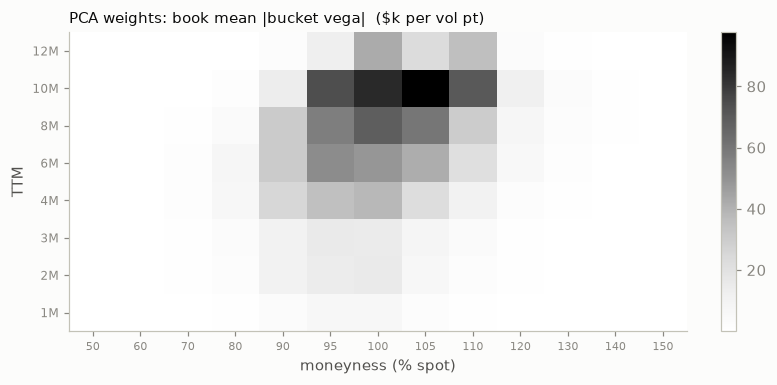

mean |bucket vega| per pillar ($k of P&L per 1 vol-pt surface move):
      50   60   70   80    90    95   100   105   110   120  130  140  150
1M   0.0  0.0  0.2  0.6   3.0   5.8   6.5   2.3   0.5   0.1  0.0  0.0  0.0
2M   0.0  0.1  0.6  2.3  10.2  14.3  15.3   6.8   2.2   0.5  0.1  0.0  0.0
3M   0.0  0.2  0.8  2.7  10.2  15.3  14.7   8.4   3.5   0.7  0.2  0.0  0.0
4M   0.0  0.2  1.2  6.1  25.5  35.3  38.1  22.0  10.6   2.3  0.6  0.1  0.0
6M   0.0  0.2  1.2  6.9  30.4  52.2  48.8  41.2  21.2   5.0  1.3  0.3  0.0
8M   0.0  0.1  0.8  3.7  30.2  57.1  68.6  59.7  29.9   7.3  2.2  0.5  0.1
10M  0.0  0.1  0.3  1.6  14.1  74.1  84.2  97.7  70.5  12.1  2.7  0.6  0.1
12M  0.0  0.0  0.1  0.2   2.1  12.8  42.4  22.5  35.7   3.3  0.7  0.1  0.0

total 1,217 $k/vol pt;  share in the 95-110 columns: 84%;  share in the 6M+ rows: 78%


In [2]:
w = vega_w.reshape(nt, nm) * 0.01 / 1e3          # $k of P&L per 1 vol-pt move
fig, ax = plt.subplots(figsize=(7.2, 3.6))
im = ax.imshow(w, origin="lower", aspect="auto", cmap="Greys")
ax.set_xticks(range(nm), MON_LBL, fontsize=7)
ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
ax.set_xlabel("moneyness (% spot)")
ax.set_ylabel("TTM")
ax.set_title("PCA weights: book mean |bucket vega|  ($k per vol pt)", loc="left", fontsize=10)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

tab = pd.DataFrame(w, index=TTM_LBL, columns=MON_LBL)
print("mean |bucket vega| per pillar ($k of P&L per 1 vol-pt surface move):")
print(tab.round(1).to_string())
print(f"\ntotal {w.sum():,.0f} $k/vol pt;  share in the 95-110 columns: "
      f"{w[:, 5:9].sum() / w.sum():.0%};  share in the 6M+ rows: {w[4:].sum() / w.sum():.0%}")

## Do the factor estimates add up to the attribution vol P&L?

The test the basis was built for: with the roll folded in, the K-factor estimate should
reconcile to the attribution `vol` component on its own. At the all-factor linear limit
it does — corr 0.994, error std $8.1k against a $70k-std target — so the basis is
complete. Truncated, k=3 tracks daily moves at corr 0.91 but over-accumulates the
downward drift (−$5.6M vs −$3.1M actual over 12.5y); k=5 brings the cumulative within
$0.7M and the all-factor estimate within $0.5M.

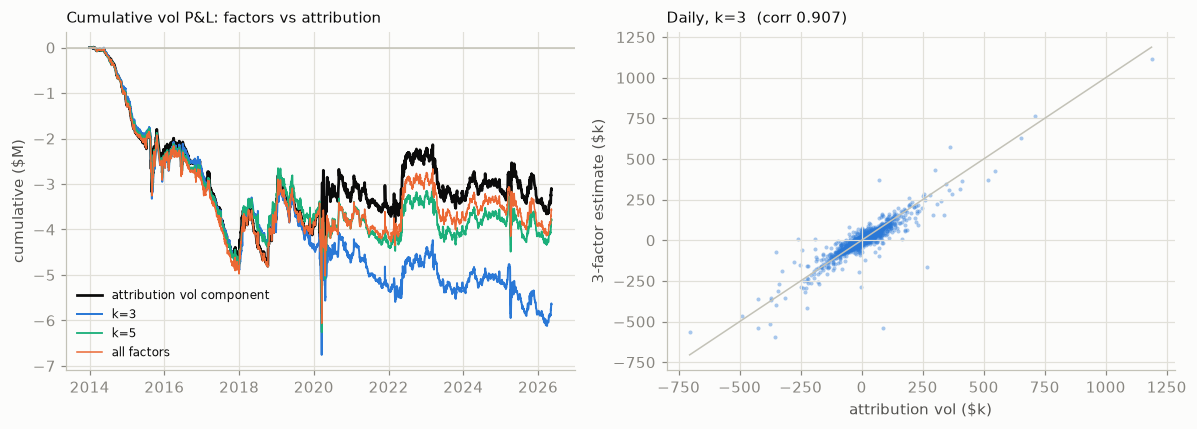

cumulative, k=  3: estimate $-5.6M vs vol $-3.1M
cumulative, k=  5: estimate $-3.8M vs vol $-3.1M
cumulative, k=104: estimate $-3.6M vs vol $-3.1M


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
d = book.index
ax.plot(d, np.cumsum(vol) / 1e6, color=INK, lw=1.8, label="attribution vol component")
for k, c, lw in ((3, C_ROLL, 1.3), (5, C_AUX, 1.2), (104, C_ALT, 1.0)):
    ax.plot(d, np.cumsum(est[k]) / 1e6, color=c, lw=lw,
            label=f"k={k}" if k < 104 else "all factors")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative ($M)")
ax.set_title("Cumulative vol P&L: factors vs attribution", loc="left", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
lim = np.array([vol[normal].min(), vol[normal].max()]) / 1e3
ax.plot(lim, lim, color="#c3c2b7", lw=1)
ax.scatter(vol[normal] / 1e3, est[3][normal] / 1e3, s=7, color=C_ROLL, alpha=0.4, lw=0)
c3 = np.corrcoef(vol[normal], est[3][normal])[0, 1]
ax.set_xlabel("attribution vol ($k)")
ax.set_ylabel("3-factor estimate ($k)")
ax.set_title(f"Daily, k=3  (corr {c3:.3f})", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

for k in (3, 5, 104):
    print(f"cumulative, k={k:>3}: estimate ${est[k].sum() / 1e6:+.1f}M "
          f"vs vol ${vol.sum() / 1e6:+.1f}M")

## Estimate quality by factor count

Two ways to reach the same target: the **roll-in factors** alone, or the headline setup
(**ex-roll factors + the ex-ante carry** forecast from the previous close). They are
nearly indistinguishable in R² — folding the roll in neither helps nor hurts the
factors, it just moves the carry from a separate forecast line into the factor mean —
with the roll-in basis a hair ahead at every k.

         R²    corr  err std ($)  |err| p99 ($)  R² ex-roll + carry
k                                                                  
1    0.5527  0.7606   46855.0353    193899.2455              0.5490
2    0.6486  0.8095   41530.5315    179060.8190              0.6409
3    0.8201  0.9073   29717.1827    115235.2327              0.8145
5    0.8605  0.9301   26161.8836     82926.1082              0.8599
10   0.9373  0.9691   17545.7781     57073.1776              0.9366
104  0.9867  0.9935    8067.0683     13992.6265              0.9863


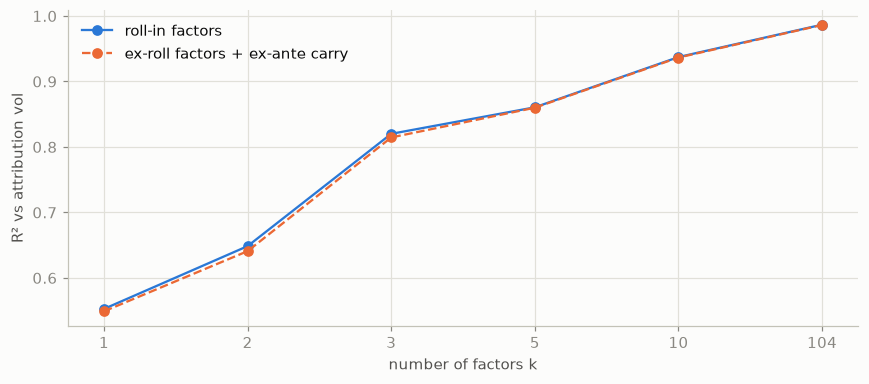

In [4]:
rows = []
for k in ks:
    err = vol[normal] - est[k][normal]
    err_alt = vol[normal] - (est_x[k] + carry)[normal]
    rows.append({"k": k,
                 "R\u00b2": 1 - err.var() / vol[normal].var(),
                 "corr": np.corrcoef(vol[normal], est[k][normal])[0, 1],
                 "err std ($)": err.std(),
                 "|err| p99 ($)": np.percentile(np.abs(err), 99),
                 "R\u00b2 ex-roll + carry": 1 - err_alt.var() / vol[normal].var()})
tab = pd.DataFrame(rows).set_index("k")
print(tab.round(4).to_string())

x = np.arange(len(ks))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(x, tab["R\u00b2"], "o-", color=C_ROLL, label="roll-in factors")
ax.plot(x, tab["R\u00b2 ex-roll + carry"], "o--", color=C_ALT,
        label="ex-roll factors + ex-ante carry")
ax.set_xticks(x, [str(k) for k in ks])
ax.set_xlabel("number of factors k")
ax.set_ylabel("R\u00b2 vs attribution vol")
ax.legend()
plt.tight_layout(); plt.show()

## The factors themselves barely notice the roll

The roll is a small, nearly deterministic daily decrement, so it cannot create variance
for PCA to reorganize: the loadings are identical to the ex-roll basis (|corr| 1.000 for
PC1–3) and the explained-variance split is unchanged (PC1 94.1%, top-3 98.0%). What the
roll *does* change is the mean: the per-pillar average change now contains the
term-structure slope × dt (left panel), and the factor-model drift `bucket_vega·μ` runs
≈ −$5.3k/day. PC1 stays nearly spot-orthogonal (right panel).

loading |corr|, roll-in vs ex-roll basis: PC1 1.000  PC2 1.000  PC3 1.000
EVR roll-in : PC1 94.1%  PC2 2.9%  PC3 1.1%
EVR ex-roll : PC1 94.2%  PC2 2.8%  PC3 1.1%


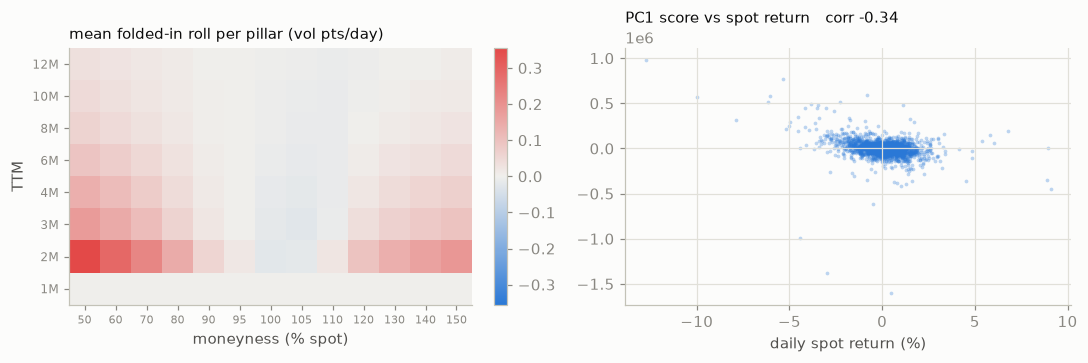

In [5]:
print("loading |corr|, roll-in vs ex-roll basis:",
      "  ".join(f"PC{i+1} {abs(np.corrcoef(model.components[i], model_x.components[i])[0, 1]):.3f}"
                for i in range(3)))
print("EVR roll-in :", "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(model.evr[:3])))
print("EVR ex-roll :", "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(model_x.evr[:3])))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
mu_roll = (model.mu - model_x.mu).reshape(nt, nm) * 100
v = np.abs(mu_roll).max()
im = axes[0].imshow(mu_roll, origin="lower", aspect="auto", cmap=DIV_CMAP, vmin=-v, vmax=v)
axes[0].set_xticks(range(nm), MON_LBL, fontsize=7)
axes[0].set_yticks(range(nt), TTM_LBL, fontsize=8)
axes[0].set_xlabel("moneyness (% spot)")
axes[0].set_ylabel("TTM")
axes[0].set_title("mean folded-in roll per pillar (vol pts/day)", loc="left", fontsize=10)
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], fraction=0.046)

f = factor_scores(dsigma, model)
r = np.corrcoef(f[normal, 0], ret[normal])[0, 1]
axes[1].scatter(ret[normal] * 100, f[normal, 0], s=6, alpha=0.3, color=C_ROLL, lw=0)
axes[1].set_xlabel("daily spot return (%)")
axes[1].set_title(f"PC1 score vs spot return   corr {r:+.2f}", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## Is 3 or 5 factors enough?

Depends on the use. Daily co-movement: k=3 explains R² 0.82 of the vol component and
k=5 adds little (0.86). The tails are where they differ: on the 173 days with |spot
return| > 2% — the days VaR lives on — k=3 manages only R² 0.66 and k=5 does *not* fix
it (PC4–5 are small smile-reshaping modes, not stress modes); it takes k=10 to reach
R² 0.83 on those days and to pull the 99th-percentile daily error down from $115k (k=3)
to $57k, against a $70k-std target.

In [6]:
big = normal & (np.abs(ret) > 0.02)
rows = []
for k in ks:
    err = vol[big] - est[k][big]
    rows.append({"k": k,
                 "R\u00b2 (|ret|>2%)": 1 - err.var() / vol[big].var(),
                 "err std ($, |ret|>2%)": err.std()})
print(f"{big.sum()} days with |spot return| > 2%")
print(pd.DataFrame(rows).set_index("k").round(3).to_string())

173 days with |spot return| > 2%
     R² (|ret|>2%)  err std ($, |ret|>2%)
k                                        
1            0.297             130787.459
2            0.484             112120.188
3            0.661              90885.233
5            0.631              94738.116
10           0.832              63895.683
104          0.958              32037.707


## Takeaways

- **The reconciliation works.** With the roll folded in, the factor basis is complete
  against the attribution `vol` component: the all-factor linear estimate matches it at
  corr 0.994 (R² 0.987, error std $8.1k), and cumulatively lands within $0.5M of the
  actual −$3.1M over 12.5 years — no separate carry line needed.
- **Folding the roll in is free but not transformative.** Loadings and EVR are identical
  to the ex-roll basis (roll has almost no variance to reorganize); the roll simply moves
  from an explicit ex-ante carry forecast into the factor mean (≈ −$5.3k/day). R² is a
  hair better than ex-roll + carry at every k, so it is a perfectly good — slightly
  simpler — formulation of the same model.
- **k=3 is enough for exposure reporting, not for tails.** Daily R² 0.82 / corr 0.91,
  but big-move-day R² is 0.66, p99 daily error $115k, and the cumulative drift
  over-shoots by $2.5M. k=5 fixes the cumulative (within $0.7M) and the p99 ($83k) but
  not the big-move days (0.63).
- **For VaR, use k≈10.** R² 0.94 overall, 0.83 on >2% spot days, p99 error $57k. The
  stress response of this book needs the higher factors — PC4–5 are smile-reshaping
  modes, not crash modes.

Next: historical VaR — full revaluation vs the K-factor estimate, using this roll-in
basis (or equivalently ex-roll factors + carry) at k=3/5/10.